# Two-Stage GOAT: U_XX Gate Synthesis

## previous GOAT runs stuck at 0.50: 
4/8 fidelity = electron-only solution, ESR + Ising can control electron sector but cant flip nuclei (no commutator of sigma_z_n generates sigma_x_n) => optimiser settles for local max since NMR gradient is ~(0.689/47.5)^2 ~ 10^-4 relative to ESR.

## => two-stage warm start

**Stage 1**: Set ESR bound = NMR bound (~4.33 rad/us) => both channels with equal gradient magnitude  => supresses electron-only solution. 


**Stage 2**: Start from Stage 1 freq components, increase ESR bound to 300 rad/us => more ESR power to refine

## Ansatz:

paper's optimal pulse peaks at hyperfine frequencies A1/2, A2/2, (A1+/-A2)/2, etc. 
Using N_FREQ=15 sinusoids / channel (180 params total, >> the 63-dim SU(8) minimum) with seeds at these freqs

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from qutip import sigmax, sigmay, sigmaz, qeye, tensor, Qobj
from qutip_qoc import Objective, optimize_pulses
from scipy.fft import rfft, rfftfreq
import functools, time, copy
import scipy.optimize

TWO_PI = 2 * np.pi
print(f'qutip {qt.__version__}')

qutip 5.2.3


In [8]:
# Physical params (paper Ustun et al. 2024)
GAMMA_E_ABS = 27_970.0   # MHz/T
GAMMA_N     = 17.23       # MHz/T
B0  = 1.33; A1 = 95.0; A2 = 9.0; B1_MAX = 0.040

OMEGA_ESR_MAX = TWO_PI * GAMMA_E_ABS * B1_MAX  # 7029 rad/us
OMEGA_NMR_MAX = TWO_PI * GAMMA_N * B1_MAX       # 4.33 rad/us

I2 = qeye(2)
sx, sy, sz = sigmax(), sigmay(), sigmaz()
def e_op(op):  return tensor(op, I2, I2)
def n1_op(op): return tensor(I2, op, I2)
def n2_op(op): return tensor(I2, I2, op)
def gate_fidelity(U, V):
    d = U.shape[0]
    return float(np.abs(np.trace(U.full().conj().T @ V.full()))) / d

# Rotating-frame drift & controls
H_drift = TWO_PI * A1/4 * e_op(sz)*n1_op(sz) + TWO_PI * A2/4 * e_op(sz)*n2_op(sz)
H_ctrl = [e_op(sx)/2, e_op(sy)/2, (n1_op(sx)+n2_op(sx))/2, (n1_op(sy)+n2_op(sy))/2]
LABELS = ['ESR_x', 'ESR_y', 'NMR_x', 'NMR_y']
N_CTRL = 4

U_XX = Qobj(0.5*np.array([
    [ 1, 0, 0, 1, 1, 0, 0,-1],[ 0, 1, 1, 0, 0, 1,-1, 0],
    [ 0, 1, 1, 0, 0,-1, 1, 0],[ 1, 0, 0, 1,-1, 0, 0, 1],
    [ 1, 0, 0,-1, 1, 0, 0, 1],[ 0, 1,-1, 0, 0, 1, 1, 0],
    [ 0,-1, 1, 0, 0, 1, 1, 0],[-1, 0, 0, 1, 1, 0, 0, 1]
], dtype=complex), dims=[[2,2,2],[2,2,2]])
initial = qt.identity([2,2,2])
target = U_XX

print(f'ESR max: {OMEGA_ESR_MAX:.1f} rad/us | NMR max: {OMEGA_NMR_MAX:.2f} rad/us')
print(f'Drift eigs (MHz): {np.sort(H_drift.eigenenergies()/TWO_PI).round(2)}')

ESR max: 7029.6 rad/us | NMR max: 4.33 rad/us
Drift eigs (MHz): [-26.  -26.  -21.5 -21.5  21.5  21.5  26.   26. ]


In [9]:
# GOAT sinusoidal ansatz
N_FREQ = 15

def sin_ctrl(t, c):
    return sum(c[k]*np.sin(c[k+1]*t + c[k+2]) for k in range(0, len(c), 3))

def sin_grad(t, c, idx):
    k0 = (idx//3)*3; r = idx%3
    a, w, phi = c[k0], c[k0+1], c[k0+2]
    if r==0: return np.sin(w*t + phi)
    if r==1: return a*t*np.cos(w*t + phi)
    if r==2: return a*np.cos(w*t + phi)

n_par_ch = N_FREQ * 3
n_total = N_CTRL * n_par_ch
print(f'{N_FREQ} freq/ch, {n_par_ch} params/ch, {n_total} total')
print(f'ODE dimension: {64*(n_total+1)}')
print(f'SU(8) dimension: 63 -> {n_total/63:.1f}x overparameterized')

15 freq/ch, 45 params/ch, 180 total
ODE dimension: 11584
SU(8) dimension: 63 -> 2.9x overparameterized


In [10]:
# Seed frequencies from paper spectrum (hyperfine transition frequencies in rotating frame)
SEED_FREQS = [
    A2/2, A2/4, A1/4, (A1-A2)/4, (A1+A2)/4,
    A2, A1/2, (A1-A2)/2, (A1+A2)/2,
    A1, 3*A2/2, A1/3, 2*A2, A2/3, 3*A1/4,
]

T_GATE = 4.0    # us
N_PTS  = 2000
W_MAX  = TWO_PI * 200  # 200 MHz
times  = np.linspace(0, T_GATE, N_PTS)

def make_ctrl_params(esr_bound, nmr_bound, esr_init_frac=0.10, nmr_init_frac=0.10):
    """Build ctrl_params dict w given bounds & initial amp fractions."""
    def _guess(amp, frac):
        g = []
        for k, f in enumerate(SEED_FREQS):
            a0 = amp * frac * (1 + 0.05*(k%5))
            g += [a0, TWO_PI * f, k * np.pi / N_FREQ]
        return g
    def _bounds(amp):
        b = []
        for _ in range(N_FREQ):
            b += [(-amp, amp), (0, W_MAX), (-np.pi, np.pi)]
        return b
    
    cp = {}
    for lab in LABELS:
        if 'ESR' in lab:
            cp[lab] = {'guess': _guess(esr_bound, esr_init_frac),
                       'bounds': _bounds(esr_bound)}
        else:
            cp[lab] = {'guess': _guess(nmr_bound, nmr_init_frac),
                       'bounds': _bounds(nmr_bound)}
    return cp

print(f'T = {T_GATE} us, {N_PTS} pts, dt = {T_GATE/N_PTS*1e3:.1f} ns')
print(f'Seed freqs (MHz): {[round(f,1) for f in SEED_FREQS]}')

T = 4.0 us, 2000 pts, dt = 2.0 ns
Seed freqs (MHz): [4.5, 2.2, 23.8, 21.5, 26.0, 9.0, 47.5, 43.0, 52.0, 95.0, 13.5, 31.7, 18.0, 3.0, 71.2]


In [11]:
# (Helper: progress logging
_real_minimize = scipy.optimize.minimize

def run_goat(ctrl_params, label, niter=1, fid_targ=5e-3, print_every=10):
    """Run GOAT and return result, fid_log, wall_time."""
    fid_log = []
    eval_ct = [0]
    best = [1.0]
    
    H_goat = [H_drift] + [[h, sin_ctrl, {'grad': sin_grad}] for h in H_ctrl]
    
    def patched(fun, x0, *args, **kwargs):
        eval_ct[0] = 0
        t0 = time.time()
        @functools.wraps(fun)
        def logged(x, *a, **kw):
            val = fun(x, *a, **kw)
            infid = float(val) if np.isscalar(val) else float(val[0])
            eval_ct[0] += 1
            fid_log.append(infid)
            if infid < best[0]: best[0] = infid
            if eval_ct[0] % print_every == 0:
                print(f'  {label} | eval {eval_ct[0]:>4d} | '
                      f'infid {infid:.6f} | best {best[0]:.6f} '
                      f'(fid {1-best[0]:.6f}) | {time.time()-t0:.0f}s')
            return val
        return _real_minimize(logged, x0, *args, **kwargs)
    
    scipy.optimize.minimize = patched
    t_start = time.time()
    try:
        res = optimize_pulses(
            objectives=Objective(initial, H_goat, target),
            control_parameters=ctrl_params,
            tlist=times,
            algorithm_kwargs={'alg': 'GOAT', 'fid_err_targ': fid_targ},
            optimizer_kwargs={'niter': niter},
            integrator_kwargs={'nsteps': 100_000, 'atol': 1e-8, 'rtol': 1e-6},
        )
    finally:
        scipy.optimize.minimize = _real_minimize
    
    wall = time.time() - t_start
    fid = 1 - res.infidelity
    print(f'\n  {label} DONE: fid = {fid:.6f}, {wall:.0f}s ({wall/60:.1f}min), '
          f'{len(fid_log)} evals')
    return res, fid_log, wall

In [12]:
%%time
# ============================================================
# STAGE 1: Equal bounds (ESR = NMR = 4.33 rad/µs)
#
# ESR Rabi rate: only 0.689 MHz (too weak to dominate)
# => equal gradient magnitude for both channels
# Ising drift (150 rad/µs >> 4 rad/µs) does the entangling.
# ============================================================

print('STAGE 1: Equal bounds (ESR = NMR)')
print(f'  ESR bound = NMR bound = {OMEGA_NMR_MAX:.2f} rad/us ({OMEGA_NMR_MAX/TWO_PI:.3f} MHz)')
print(f'  ESR/NMR ratio: 1:1')
print(f'  Drift/control ratio: {(TWO_PI*A1/4)/OMEGA_NMR_MAX:.0f}:1 (drift-dominated)\n')

cp_stage1 = make_ctrl_params(
    esr_bound=OMEGA_NMR_MAX,    # = NMR!
    nmr_bound=OMEGA_NMR_MAX,
    esr_init_frac=0.30,          # both 30%
    nmr_init_frac=0.30,
)

res1, log1, wall1 = run_goat(cp_stage1, 'Stage1', niter=1)

STAGE 1: Equal bounds (ESR = NMR)
  ESR bound = NMR bound = 4.33 rad/us (0.689 MHz)
  ESR/NMR ratio: 1:1
  Drift/control ratio: 34:1 (drift-dominated)

  Stage1 | eval   10 | infid 0.386894 | best 0.386894 (fid 0.613106) | 2026s
  Stage1 | eval   20 | infid 0.128200 | best 0.128200 (fid 0.871800) | 12990s
  Stage1 | eval   30 | infid 0.086339 | best 0.086339 (fid 0.913661) | 17179s
  Stage1 | eval   40 | infid 0.055451 | best 0.055451 (fid 0.944549) | 18286s
  Stage1 | eval   50 | infid 0.023874 | best 0.023874 (fid 0.976126) | 19405s
  Stage1 | eval   60 | infid 0.014171 | best 0.009130 (fid 0.990870) | 20516s
  Stage1 | eval   70 | infid 0.005980 | best 0.005980 (fid 0.994020) | 21623s
  Stage1 | eval   10 | infid 0.031800 | best 0.004861 (fid 0.995139) | 7772s
  Stage1 | eval   20 | infid 0.008022 | best 0.004861 (fid 0.995139) | 9529s
  Stage1 | eval   30 | infid 0.006544 | best 0.004861 (fid 0.995139) | 10632s
  Stage1 | eval   40 | infid 0.005198 | best 0.004861 (fid 0.995139) | 

In [13]:
# Print Stage 1 result and check if it broke 0.50
fid1 = 1 - res1.infidelity
print(f'Stage 1 fidelity: {fid1:.6f}')
print(f'Stage 1 peak amplitudes:')
for i, lab in enumerate(LABELS):
    p = res1.optimized_params[i]
    mx = max(abs(p[3*k]) for k in range(N_FREQ))
    print(f'  {lab}: {mx:.3f} rad/us ({mx/OMEGA_NMR_MAX*100:.1f}% of NMR bound)')

if fid1 > 0.52:
    print(f'\n>>> Stage 1 broke 0.50! Nuclear channels are engaging.')
    print(f'    Proceeding to Stage 2 with increased ESR bound.')
else:
    print(f'\n>>> Stage 1 < 0.50 -- electron-only solution persists. / unecpected behavior')

Stage 1 fidelity: 0.995139
Stage 1 peak amplitudes:
  ESR_x: 1.658 rad/us (38.3% of NMR bound)
  ESR_y: 1.873 rad/us (43.3% of NMR bound)
  NMR_x: 1.911 rad/us (44.1% of NMR bound)
  NMR_y: 4.168 rad/us (96.3% of NMR bound)

>>> Stage 1 broke 0.50! Nuclear channels are engaging.
    Proceeding to Stage 2 with increased ESR bound.


In [14]:
%%time
# ============================================================
# STAGE 2: Warm-start with increased ESR bound
#
# initial guess: take Stage 1 optimised params
# Increase ESR bound to 300 rad/us (48 MHz Rabi).
# ============================================================

ESR_BOUND_2 = 300.0  # rad/us

print(f'STAGE 2: Warm-start with ESR bound = {ESR_BOUND_2} rad/us')
print(f'  ESR/NMR ratio: {ESR_BOUND_2/OMEGA_NMR_MAX:.0f}:1')
print(f'  Warm-starting from Stage 1 (fid={fid1:.4f})\n')

# warm-start ctrl_params from Stage 1 res
cp_stage2 = {}
for i, lab in enumerate(LABELS):
    amp = ESR_BOUND_2 if 'ESR' in lab else OMEGA_NMR_MAX
    bounds = []
    for _ in range(N_FREQ):
        bounds += [(-amp, amp), (0, W_MAX), (-np.pi, np.pi)]
    cp_stage2[lab] = {
        'guess': list(res1.optimized_params[i]),  # warm start
        'bounds': bounds,
    }

res2, log2, wall2 = run_goat(cp_stage2, 'Stage2', niter=1)

STAGE 2: Warm-start with ESR bound = 300.0 rad/us
  ESR/NMR ratio: 69:1
  Warm-starting from Stage 1 (fid=0.9951)

  Stage2 | eval   10 | infid 0.028930 | best 0.004811 (fid 0.995189) | 7685s
  Stage2 | eval   20 | infid 0.008429 | best 0.004811 (fid 0.995189) | 11471s
  Stage2 | eval   30 | infid 0.006194 | best 0.004811 (fid 0.995189) | 18277s
  Stage2 | eval   40 | infid 0.004956 | best 0.004811 (fid 0.995189) | 23621s

  Stage2 DONE: fid = 0.995189, 23953s (399.2min), 43 evals
CPU times: user 1h 18min 14s, sys: 10 s, total: 1h 18min 24s
Wall time: 6h 39min 13s


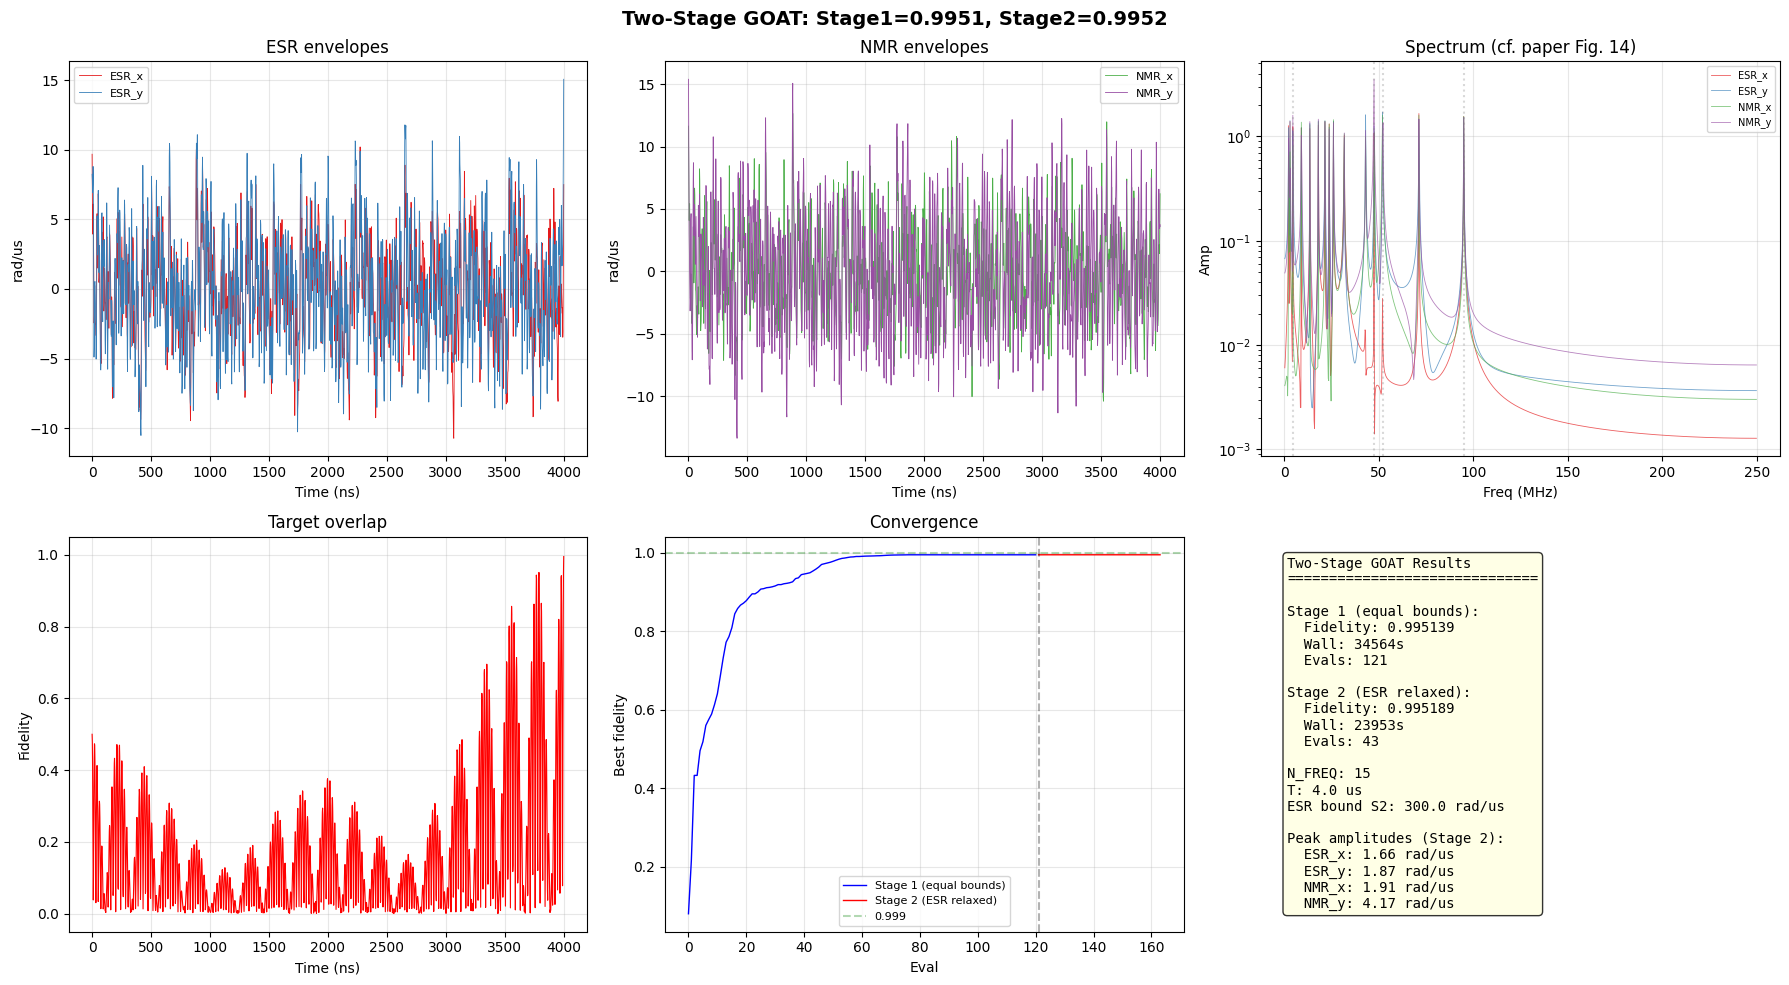

In [15]:
# ============================================================
# Results comparison
# ============================================================

fid2 = 1 - res2.infidelity

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colours = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

# Stage 2 result
res_plot = res2
ctrls = [np.array(res_plot.optimized_controls[i]) for i in range(N_CTRL)]
dt = times[1] - times[0]

# (a) ESR
for i in [0,1]:
    axes[0,0].plot(times*1e3, ctrls[i], lw=0.6, color=colours[i], label=LABELS[i])
axes[0,0].set(xlabel='Time (ns)', ylabel='rad/us', title='ESR envelopes')
axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)

# (b) NMR
for i in [2,3]:
    axes[0,1].plot(times*1e3, ctrls[i], lw=0.6, color=colours[i], label=LABELS[i])
axes[0,1].set(xlabel='Time (ns)', ylabel='rad/us', title='NMR envelopes')
axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

# (c) Spectrum
for i in range(N_CTRL):
    freqs = rfftfreq(len(ctrls[i]), d=dt)
    spec = np.abs(rfft(ctrls[i])) * 2 / len(ctrls[i])
    mask = freqs > 0
    axes[0,2].semilogy(freqs[mask], spec[mask], lw=0.6, color=colours[i],
                       label=LABELS[i], alpha=0.7)
for f in [A2/2, A1/2, A1, (A1+A2)/2]:
    axes[0,2].axvline(f, color='gray', ls=':', alpha=0.3)
axes[0,2].set(xlabel='Freq (MHz)', ylabel='Amp', title='Spectrum (cf. paper Fig. 14)')
axes[0,2].legend(fontsize=7); axes[0,2].grid(True, alpha=0.3)

# (d) Overlap dynamics
H_evo = [H_drift] + [[H_ctrl[i], ctrls[i]] for i in range(N_CTRL)]
try:
    evo = qt.sesolve(H_evo, initial, times)
    ov = [gate_fidelity(s, target) for s in evo.states]
    axes[1,0].plot(times*1e3, ov, 'r-', lw=0.8)
except Exception as e:
    axes[1,0].text(0.5,0.5,str(e)[:100],transform=axes[1,0].transAxes,ha='center')
axes[1,0].set(xlabel='Time (ns)', ylabel='Fidelity', title='Target overlap',
              ylim=(-0.05,1.05))
axes[1,0].grid(True, alpha=0.3)

# (e) Convergence
if log1:
    axes[1,1].plot(range(len(log1)), [1-v for v in np.minimum.accumulate(log1)],
                   'b-', lw=1, label='Stage 1 (equal bounds)')
if log2:
    x2 = range(len(log1), len(log1)+len(log2))
    axes[1,1].plot(x2, [1-v for v in np.minimum.accumulate(log2)],
                   'r-', lw=1, label='Stage 2 (ESR relaxed)')
    axes[1,1].axvline(len(log1), color='k', ls='--', alpha=0.3)
axes[1,1].axhline(0.999, color='g', ls='--', alpha=0.3, label='0.999')
axes[1,1].set(xlabel='Eval', ylabel='Best fidelity', title='Convergence')
axes[1,1].legend(fontsize=8); axes[1,1].grid(True, alpha=0.3)

# (f) Summary
axes[1,2].axis('off')
lines = [
    'Two-Stage GOAT Results', '='*30, '',
    f'Stage 1 (equal bounds):', f'  Fidelity: {fid1:.6f}',
    f'  Wall: {wall1:.0f}s', f'  Evals: {len(log1)}', '',
    f'Stage 2 (ESR relaxed):', f'  Fidelity: {fid2:.6f}',
    f'  Wall: {wall2:.0f}s', f'  Evals: {len(log2)}', '',
    f'N_FREQ: {N_FREQ}', f'T: {T_GATE} us',
    f'ESR bound S2: {ESR_BOUND_2} rad/us', '',
    'Peak amplitudes (Stage 2):',
]
for i, lab in enumerate(LABELS):
    p = res2.optimized_params[i]
    mx = max(abs(p[3*k]) for k in range(N_FREQ))
    lines.append(f'  {lab}: {mx:.2f} rad/us')
axes[1,2].text(0.05, 0.95, '\n'.join(lines), transform=axes[1,2].transAxes,
               fontsize=10, va='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle(f'Two-Stage GOAT: Stage1={fid1:.4f}, Stage2={fid2:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Print optimized sinusoidal components
print('Stage 2 optimized components:')
for i, lab in enumerate(LABELS):
    p = res2.optimized_params[i]
    print(f'\n{lab}:')
    for k in range(N_FREQ):
        a, w, phi = p[3*k], p[3*k+1], p[3*k+2]
        print(f'  comp {k:2d}: amp={a:>8.3f}  f={w/TWO_PI:>7.2f} MHz  phi={phi:>6.3f}')

Stage 2 optimized components:

ESR_x:
  comp  0: amp=   1.223  f=   4.49 MHz  phi=-0.022
  comp  1: amp=   1.285  f=   2.24 MHz  phi= 0.167
  comp  2: amp=   1.311  f=  23.75 MHz  phi= 0.391
  comp  3: amp=   1.368  f=  21.50 MHz  phi= 0.606
  comp  4: amp=   1.406  f=  26.01 MHz  phi= 0.834
  comp  5: amp=   1.200  f=   8.99 MHz  phi= 1.023
  comp  6: amp=   1.071  f=  47.48 MHz  phi= 1.211
  comp  7: amp=  -0.021  f=  42.90 MHz  phi= 1.311
  comp  8: amp=   0.029  f=  51.90 MHz  phi= 1.327
  comp  9: amp=   1.603  f=  94.99 MHz  phi= 1.872
  comp 10: amp=   1.199  f=  13.51 MHz  phi= 2.122
  comp 11: amp=   1.201  f=  31.66 MHz  phi= 2.298
  comp 12: amp=   1.321  f=  18.02 MHz  phi= 2.558
  comp 13: amp=   1.407  f=   3.01 MHz  phi= 2.759
  comp 14: amp=   1.658  f=  71.22 MHz  phi= 2.880

ESR_y:
  comp  0: amp=   1.264  f=   4.56 MHz  phi= 0.012
  comp  1: amp=   1.253  f=   2.30 MHz  phi= 0.182
  comp  2: amp=   1.273  f=  23.77 MHz  phi= 0.272
  comp  3: amp=   1.503  f=  21.54 M

## Lab-frame verification (exact)

propagating the **full lab-frame Hamiltonian** & comparing result to exact target

**Lab-frame Hamiltonian**:

$$H_\text{lab}(t) = \frac{\omega_e}{2}\sigma_z^e + \frac{\omega_n}{2}(\sigma_z^{n_1}+\sigma_z^{n_2})
+ \sum_k \frac{2\pi A_k}{4}\,\sigma_z^e\sigma_z^{n_k}
+ \Omega_\text{ESR}(t)\,\sigma_x^e + \Omega_\text{NMR}(t)\,(\sigma_x^{n_1}+\sigma_x^{n_2})$$

w physical drive fields reconstructed from the rotating-frame envelopes:

$$\Omega_\text{ESR}(t) = u_x^e(t)\cos\omega_e t + u_y^e(t)\sin\omega_e t$$

**Fidelity comparison:** lab-frame propagator includes Zeeman precession => compare $U_\text{lab}(T)$ with $R(T)\,U_{XX}$ where
$R(T) = e^{-i\omega_e T\sigma_z^e/2} \otimes e^{-i\omega_n T\sigma_z^{n_1}/2} \otimes e^{-i\omega_n T\sigma_z^{n_2}/2}$.

In [17]:
%%time
# ============================================================
# Direct lab-frame verification
#
# Reconstruct physical (lab-frame) Hamiltonian from rotating-frame optimized pulse & propagate exactly
# ============================================================
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# Larmor freqs (rad/µs)
omega_e = TWO_PI * GAMMA_E_ABS * B0   # electron: ~2π * 37200 MHz
omega_n = TWO_PI * GAMMA_N * B0       # nuclear:  ~2π * 22.9 MHz
T_larmor_e = TWO_PI / omega_e         # electron Larmor period in µs

print(f'Larmor frequencies:')
print(f'  electron: {omega_e/TWO_PI:.1f} MHz  (period = {T_larmor_e*1e6:.4f} ps)')
print(f'  nuclear:  {omega_n/TWO_PI:.2f} MHz  (period = {TWO_PI/omega_n*1e3:.2f} ns)')
print(f'  ratio:    {omega_e/omega_n:.0f}:1')
print()

# Static lab-frame Hamiltonian: Zeeman + Ising ZZ hyperfine
H_zeeman = (omega_e/2) * e_op(sz).full() \
         + (omega_n/2) * (n1_op(sz).full() + n2_op(sz).full())
H_hf     = H_drift.full()  # Ising ZZ — identical in both frames
H_static = H_zeeman + H_hf

# Lab-frame control ops (full sigma)
# (factor of 2 vs rotating frame accounts for RWA: rotating-frame amplitude u(t) * sigma/2  <-> lab-frame u(t)*cos(wt) * sigma
sigma_x_e = e_op(sx).full()                      # 8x8
sigma_x_n = (n1_op(sx) + n2_op(sx)).full()        # 8x8 (shared coil)

# Interpolators for rotating-frame envelopes
ctrls_s2 = [np.array(res2.optimized_controls[i]) for i in range(N_CTRL)]
u_esr_x = interp1d(times, ctrls_s2[0], kind='cubic', fill_value=0, bounds_error=False)
u_esr_y = interp1d(times, ctrls_s2[1], kind='cubic', fill_value=0, bounds_error=False)
u_nmr_x = interp1d(times, ctrls_s2[2], kind='cubic', fill_value=0, bounds_error=False)
u_nmr_y = interp1d(times, ctrls_s2[3], kind='cubic', fill_value=0, bounds_error=False)

def H_lab(t):
    """Full lab-frame Hamiltonian at time t (8x8 complex array).
    
    Physical (linearly polarized) drives reconstructed from rotating-frame envelopes:
      Omega_ESR(t) = u_esr_x(t) cos(omega_e t) + u_esr_y(t) sin(omega_e t)
      Omega_NMR(t) = u_nmr_x(t) cos(omega_n t) + u_nmr_y(t) sin(omega_n t)
    """
    ex, ey = float(u_esr_x(t)), float(u_esr_y(t))
    nx, ny = float(u_nmr_x(t)), float(u_nmr_y(t))
    
    cos_e, sin_e = np.cos(omega_e * t), np.sin(omega_e * t)
    cos_n, sin_n = np.cos(omega_n * t), np.sin(omega_n * t)
    
    drive_esr = ex * cos_e + ey * sin_e   # scalar lab-frame ESR amp
    drive_nmr = nx * cos_n + ny * sin_n   # scalar lab-frame NMR amp
    
    return H_static + drive_esr * sigma_x_e + drive_nmr * sigma_x_n

# ============================================================
# Propagate: dU/dt = -i H(t) U,  U(0) = I
# Flatten 8x8 unitary → 128-element real vector
# ============================================================
N = 8

def rhs(t, y):
    U = y.reshape(N, N)
    H = H_lab(t)
    dU = -1j * H @ U
    return dU.ravel()

U0 = np.eye(N, dtype=complex).ravel()

# DOP853 = 8th-order Dormand-Prince
# max_step ~ 1/4 of Larmor period (so solver tracks 37 GHz oscillation)
max_dt = T_larmor_e / 4   # ~6.7 ps

print(f'Propagating lab-frame Hamiltonian (T = {T_GATE} us)...')
print(f'  Fastest oscillation: {omega_e/TWO_PI:.0f} MHz (period {T_larmor_e*1e6:.1f} ps)')
print(f'  max_step = {max_dt*1e6:.1f} ps ({T_GATE/max_dt:.0f} minimum steps)')
print(f'  Method: DOP853 (8th-order), rtol=1e-8, atol=1e-10')
t0_wall = time.time()

sol = solve_ivp(
    rhs, [0, T_GATE], U0,
    method='DOP853',
    rtol=1e-8, atol=1e-10,
    max_step=max_dt,
    dense_output=False,
)

wall_lab = time.time() - t0_wall
print(f'  Done in {wall_lab:.1f}s ({wall_lab/60:.1f} min)')
print(f'  ODE evaluations: {sol.nfev}')
print(f'  Steps taken:     {sol.t.size}')
print(f'  Status: {sol.message}')

# Extract final propagator
U_lab_final = sol.y[:, -1].reshape(N, N)

# Frame rotation: R(T) = exp(-i H_Zeeman T) = tensor prod. of single-spin rotations
R_e  = np.diag([np.exp(-1j*omega_e*T_GATE/2), np.exp(+1j*omega_e*T_GATE/2)])
R_n1 = np.diag([np.exp(-1j*omega_n*T_GATE/2), np.exp(+1j*omega_n*T_GATE/2)])
R_n2 = np.diag([np.exp(-1j*omega_n*T_GATE/2), np.exp(+1j*omega_n*T_GATE/2)])
R_T  = np.kron(R_e, np.kron(R_n1, R_n2))

# Lab-frame target: R(T) * U_XX 
U_lab_target = R_T @ U_XX.full()

# Gate fidelity: |Tr(U_target† U_lab)| / d
fid_lab = np.abs(np.trace(U_lab_target.conj().T @ U_lab_final)) / N

# Sanity check unitarity of numerical res
unitarity_err = np.linalg.norm(U_lab_final.conj().T @ U_lab_final - np.eye(N))

print(f'\n{"="*60}')
print(f'  LAB-FRAME VERIFICATION (EXACT)')
print(f'{"="*60}')
print(f'Rotating-frame fidelity (RWA):  {fid2:.6f}')
print(f'Lab-frame fidelity (exact):     {fid_lab:.6f}')
print(f'Fidelity drop from RWA:         {fid2 - fid_lab:.6f}')
print(f'Unitarity error (should be <1e-6): {unitarity_err:.2e}')
print(f'Wall time:                      {wall_lab:.1f}s')
print()

if fid_lab > 0.99:
    print('>>> rotating-frame pulse works in lab frame.')
elif fid_lab > 0.95:
    print('>>> Moderate RWA err. The pulse may need refinement.')
else:
    print('>>> Large discrepancy')

Larmor frequencies:
  electron: 37200.1 MHz  (period = 26.8816 ps)
  nuclear:  22.92 MHz  (period = 43.64 ns)
  ratio:    1623:1

Propagating lab-frame Hamiltonian (T = 4.0 us)...
  Fastest oscillation: 37200 MHz (period 26.9 ps)
  max_step = 6.7 ps (595202 minimum steps)
  Method: DOP853 (8th-order), rtol=1e-8, atol=1e-10
  Done in 557.0s (9.3 min)
  ODE evaluations: 9893090
  Steps taken:     824424
  Status: The solver successfully reached the end of the integration interval.

  LAB-FRAME VERIFICATION (EXACT)
Rotating-frame fidelity (RWA):  0.995189
Lab-frame fidelity (exact):     0.978567
Fidelity drop from RWA:         0.016622
Unitarity error (should be <1e-6): 3.73e-04
Wall time:                      557.0s

>>> Moderate RWA error. The pulse may need refinement.
CPU times: user 9min 15s, sys: 1.69 s, total: 9min 16s
Wall time: 9min 16s


## Stage 3: Higher spectral resolution (N_FREQ=25)

Warm-start from Stage 2 w 25 sinusoidal components / channel (300 total params)

In [19]:
%%time
# ============================================================
# STAGE 3: N_FREQ=25, warm-start from res2
# ============================================================

N_FREQ_3 = 25
n_par_ch_3 = N_FREQ_3 * 3

res_prev = res2
fid_prev = fid2

print(f'STAGE 3: N_FREQ={N_FREQ_3} ({n_par_ch_3} params/ch, {N_CTRL*n_par_ch_3} total)')
print(f'  Warm-starting from Stage 2 (fid={fid_prev:.4f})')
print(f'  Adding {N_FREQ_3 - N_FREQ} new frequency components per channel\n')

# Extended seed frequencies
SEED_FREQS_3 = list(SEED_FREQS) + [
    A1*3/4 + A2/4, A1/2 + A2, A1 - A2/2, A2*3/4, A1/6,
    2*A1/3, A1/2 + A2/4, A2*5/4, (A1+A2)/3, 3*A2,
]

# copy N_FREQ components from res2, small-init rest
cp_stage3 = {}
for i, lab in enumerate(LABELS):
    amp = ESR_BOUND_2 if 'ESR' in lab else OMEGA_NMR_MAX
    init_frac = 0.05  # new components
    
    prev_params = list(res_prev.optimized_params[i])
    
    new_params = []
    for k in range(N_FREQ, N_FREQ_3):
        f = SEED_FREQS_3[k] if k < len(SEED_FREQS_3) else (k - N_FREQ + 1) * A2
        a0 = amp * init_frac * (0.5 + 0.5 * np.random.rand())
        new_params += [a0, TWO_PI * f, np.random.uniform(-np.pi, np.pi)]
    
    all_params = prev_params + new_params
    bounds = [(-amp, amp), (0, W_MAX), (-np.pi, np.pi)] * N_FREQ_3
    
    cp_stage3[lab] = {'guess': all_params, 'bounds': bounds}

H_goat_3 = [H_drift] + [[h, sin_ctrl, {'grad': sin_grad}] for h in H_ctrl]

# run w progress logging
fid_log_3 = []
eval_ct_3 = [0]
best_3 = [1.0]

def patched_3(fun, x0, *args, **kwargs):
    eval_ct_3[0] = 0
    t0 = time.time()
    @functools.wraps(fun)
    def logged(x, *a, **kw):
        val = fun(x, *a, **kw)
        infid = float(val) if np.isscalar(val) else float(val[0])
        eval_ct_3[0] += 1
        fid_log_3.append(infid)
        if infid < best_3[0]: best_3[0] = infid
        if eval_ct_3[0] % 5 == 0:
            print(f'  Stage3 | eval {eval_ct_3[0]:>4d} | '
                  f'infid {infid:.6f} | best {best_3[0]:.6f} '
                  f'(fid {1-best_3[0]:.6f}) | {time.time()-t0:.0f}s')
        return val
    return _real_minimize(logged, x0, *args, **kwargs)

scipy.optimize.minimize = patched_3
t_start = time.time()
try:
    res3 = optimize_pulses(
        objectives=Objective(initial, H_goat_3, target),
        control_parameters=cp_stage3,
        tlist=times,
        algorithm_kwargs={'alg': 'GOAT', 'fid_err_targ': 1e-3},
        optimizer_kwargs={'niter': 0},
        integrator_kwargs={'nsteps': 100_000, 'atol': 1e-8, 'rtol': 1e-6},
    )
finally:
    scipy.optimize.minimize = _real_minimize

wall_3 = time.time() - t_start
fid_3 = 1 - res3.infidelity

print(f'\n{"="*60}')
print(f'  STAGE 3 RESULT (N_FREQ={N_FREQ_3})')
print(f'{"="*60}')
print(f'Fidelity:  {fid_3:.6f}  (infidelity {res3.infidelity:.2e})')
print(f'Wall time: {wall_3:.0f}s ({wall_3/60:.1f} min)')
print(f'Evals:     {len(fid_log_3)}')
print(f'Previous:  Stage 2 fid = {fid_prev:.6f}')
print(f'Improvement: {fid_3 - fid_prev:.6f}')

STAGE 3: N_FREQ=25 (75 params/ch, 300 total)
  Warm-starting from Stage 2 (fid=0.9952)
  Adding 10 new frequency components per channel

  Stage3 | eval   10 | infid 0.210522 | best 0.210522 (fid 0.789478) | 38828s
  Stage3 | eval   20 | infid 0.070551 | best 0.070551 (fid 0.929449) | 41840s
  Stage3 | eval   30 | infid 0.027411 | best 0.027411 (fid 0.972589) | 45666s
  Stage3 | eval   40 | infid 0.017779 | best 0.017779 (fid 0.982221) | 47992s
  Stage3 | eval   50 | infid 0.010152 | best 0.010152 (fid 0.989848) | 50154s
  Stage3 | eval   60 | infid 0.005757 | best 0.005757 (fid 0.994243) | 52322s
  Stage3 | eval   70 | infid 0.004153 | best 0.003918 (fid 0.996082) | 54492s
  Stage3 | eval   80 | infid 0.002841 | best 0.002841 (fid 0.997159) | 56722s
  Stage3 | eval   90 | infid 0.002281 | best 0.002281 (fid 0.997719) | 60556s
  Stage3 | eval  100 | infid 0.001565 | best 0.001565 (fid 0.998435) | 70741s
  Stage3 | eval  110 | infid 0.001294 | best 0.001294 (fid 0.998706) | 73132s
  Sta

# evaluate in lab frame again

In [20]:
%%time
# ==================================
# Lab-frame verification (exact) 
# ==================================

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# Pick res
for _name, _res in [('res3', 'res3'), ('res2b', 'res2b'), ('res2', 'res2')]:
    if _name in dir():
        res_verify = eval(_name)
        fid_rot_verify = 1 - res_verify.infidelity
        print(f'Verifying: {_name} (rotating-frame fid = {fid_rot_verify:.6f})')
        break

omega_e = TWO_PI * GAMMA_E_ABS * B0
omega_n = TWO_PI * GAMMA_N * B0
T_larmor_e = TWO_PI / omega_e

H_zeeman = (omega_e/2) * e_op(sz).full() \
         + (omega_n/2) * (n1_op(sz).full() + n2_op(sz).full())
H_static = H_zeeman + H_drift.full()

sigma_x_e = e_op(sx).full()
sigma_x_n = (n1_op(sx) + n2_op(sx)).full()

ctrls_v = [np.array(res_verify.optimized_controls[i]) for i in range(N_CTRL)]
u_ex = interp1d(times, ctrls_v[0], kind='cubic', fill_value=0, bounds_error=False)
u_ey = interp1d(times, ctrls_v[1], kind='cubic', fill_value=0, bounds_error=False)
u_nx = interp1d(times, ctrls_v[2], kind='cubic', fill_value=0, bounds_error=False)
u_ny = interp1d(times, ctrls_v[3], kind='cubic', fill_value=0, bounds_error=False)

def H_lab_v(t):
    ex, ey = float(u_ex(t)), float(u_ey(t))
    nx, ny = float(u_nx(t)), float(u_ny(t))
    ce, se = np.cos(omega_e * t), np.sin(omega_e * t)
    cn, sn = np.cos(omega_n * t), np.sin(omega_n * t)
    return H_static + (ex*ce + ey*se)*sigma_x_e + (nx*cn + ny*sn)*sigma_x_n

N = 8
def rhs_v(t, y):
    return (-1j * H_lab_v(t) @ y.reshape(N,N)).ravel()

max_dt = T_larmor_e / 4
print(f'max_step = {max_dt*1e6:.1f} ps, ~{T_GATE/max_dt:.0f} steps')

sol = solve_ivp(rhs_v, [0, T_GATE], np.eye(N, dtype=complex).ravel(),
                method='DOP853', rtol=1e-8, atol=1e-10,
                max_step=max_dt, dense_output=False)

U_lab = sol.y[:,-1].reshape(N,N)
R_T = np.kron(
    np.diag([np.exp(-1j*omega_e*T_GATE/2), np.exp(+1j*omega_e*T_GATE/2)]),
    np.kron(np.diag([np.exp(-1j*omega_n*T_GATE/2), np.exp(+1j*omega_n*T_GATE/2)]),
            np.diag([np.exp(-1j*omega_n*T_GATE/2), np.exp(+1j*omega_n*T_GATE/2)])))

fid_lab = np.abs(np.trace((R_T @ U_XX.full()).conj().T @ U_lab)) / N
unitarity_err = np.linalg.norm(U_lab.conj().T @ U_lab - np.eye(N))

print(f'\nRotating-frame fidelity: {fid_rot_verify:.6f}')
print(f'Lab-frame fidelity:     {fid_lab:.6f}')
print(f'Fidelity drop (RWA):    {fid_rot_verify - fid_lab:.6f}')
print(f'Unitarity error:        {unitarity_err:.2e}')
print(f'Wall time:              {sol.t[-1]:.1f} us, {sol.nfev} evals, {sol.t.size} steps')

Verifying: res3 (rotating-frame fid = 0.999020)
max_step = 6.7 ps, ~595202 steps

Rotating-frame fidelity: 0.999020
Lab-frame fidelity:     0.957047
Fidelity drop (RWA):    0.041973
Unitarity error:        3.64e-04
Wall time:              4.0 us, 9915734 evals, 826311 steps
CPU times: user 5min 24s, sys: 2.18 s, total: 5min 26s
Wall time: 5min 27s


## Save res

In [23]:
# =============================
# Save optimization results 
# =============================
import pickle, os

SAVE_DIR = '/Users/johnkraus/Desktop/Zurich Instruments/c_codespace'
os.makedirs(SAVE_DIR, exist_ok=True)

for name, res in [('res1', res1), ('res2', res2), ('res3', res3)]:
    path = os.path.join(SAVE_DIR, f'{name}.pkl')
    data = {
        'optimized_params': res.optimized_params,
        'optimized_controls': [np.array(res.optimized_controls[i]) for i in range(N_CTRL)],
        'infidelity': res.infidelity,
        'times': times,
        'N_FREQ': N_FREQ if name != 'res3' else N_FREQ_3,
        'LABELS': LABELS,
        'T_GATE': T_GATE,
    }
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f'Saved {name} (fid={1-res.infidelity:.6f}) -> {path}')

print(f'\nresults saved to {SAVE_DIR}/')
print('Load: data = pickle.load(open("path.pkl", "rb"))')

Saved res1 (fid=0.995139) -> /Users/johnkraus/Desktop/Zurich Instruments/c_codespace/res1.pkl
Saved res2 (fid=0.995189) -> /Users/johnkraus/Desktop/Zurich Instruments/c_codespace/res2.pkl
Saved res3 (fid=0.999020) -> /Users/johnkraus/Desktop/Zurich Instruments/c_codespace/res3.pkl

results saved to /Users/johnkraus/Desktop/Zurich Instruments/c_codespace/
Load: data = pickle.load(open("path.pkl", "rb"))


## check bounds

In [24]:
for i, lab in enumerate(LABELS):
    peak = np.max(np.abs(ctrls[i]))
    bound = OMEGA_ESR_MAX if 'ESR' in lab else OMEGA_NMR_MAX
    ratio = peak / bound
    flag = ' *** EXCEEDS BOUND' if ratio > 1 else ''
    print(f'{lab}: peak = {peak:.2f} rad/us, bound = {bound:.2f}, ratio = {ratio:.1f}x{flag}')

ESR_x: peak = 10.72 rad/us, bound = 7029.63, ratio = 0.0x
ESR_y: peak = 15.06 rad/us, bound = 7029.63, ratio = 0.0x
NMR_x: peak = 12.65 rad/us, bound = 4.33, ratio = 2.9x *** EXCEEDS BOUND
NMR_y: peak = 15.39 rad/us, bound = 4.33, ratio = 3.6x *** EXCEEDS BOUND
